In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# here we will now solve the equation
# dudx = 2, which has a cloased solution for the initial conditions:
# u(0,y) = y

x_sample = torch.linspace(-5, 5, 100)
y_sample = torch.linspace(0, 5, 100)
xy_sample = torch.cartesian_prod(x_sample, y_sample)
xy_sample.requires_grad = True
print(xy_sample)
print(xy_sample.shape)


tensor([[-5.0000,  0.0000],
        [-5.0000,  0.0505],
        [-5.0000,  0.1010],
        ...,
        [ 5.0000,  4.8990],
        [ 5.0000,  4.9495],
        [ 5.0000,  5.0000]], requires_grad=True)
torch.Size([10000, 2])


In [3]:
# Define the PINN model, and test for dimensional broadcasting
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),   # Input layer with 2 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for u(x,y)
        )

    def forward(self, X):
        return self.net(X)
    
pinn = PINN()

u = pinn(xy_sample)
print(u)
print(u.shape)

tensor([[ 0.0897],
        [ 0.0895],
        [ 0.0894],
        ...,
        [-0.0288],
        [-0.0283],
        [-0.0277]], grad_fn=<AddmmBackward0>)
torch.Size([10000, 1])


In [4]:
# Define the Poisson equation loss function
def pde_loss(pinn_sth, X):
    

    u = pinn_sth(X)
    vector = torch.ones_like(u)
    vector.to("cuda")

    u_X = torch.autograd.grad(u, X, grad_outputs=vector, create_graph=True)[0]
    u_x = u_X[:,0]
    u_y = u_X[:,1]
    
    loss = (2*u_x + 3*u_y + 8*u)**2

    return loss

def boundary_loss(pinn_sth):

    x_sample = torch.linspace(-5, 5, 100)
    X = torch.zeros([x_sample.shape[0], 2])
    X[:,0] = x_sample
    X = X.detach().to("cuda")
    
    y = torch.sin(x_sample).to("cuda")
    
    u = pinn_sth(X)

    loss = (y.reshape(x_sample.shape[0], 1) - u)**2

    return loss

In [5]:
# replace data with itself
xy_sample = xy_sample.detach().to("cuda:0")
xy_sample.requires_grad = True

# Create PINN model and move to gpu
pinn_model = PINN().to(torch.device("cuda:0"))

print("Checking devices")
print(f"Device of the input data is: {xy_sample.device}")
print(f"Device of the model stuff is: ")
for elem in pinn_model.net:
    try:
        print(f"\tLayer {elem} has device: {elem.weight.device} and {elem.bias.device}")
    except:
        print(f"\tLayer {elem} has no weights associated")

# optimizer
pinn_optimizer = optim.Adam(params=pinn_model.parameters(), lr=5e-4)

# loss tracking
pinn_losses = []

# Training loop
epochs = 20000
for epoch in range(epochs):
    # Compute the losses
    u_sample_estimate = pinn_model(xy_sample)
    pinn_loss = torch.mean(pde_loss(pinn_model, xy_sample)) + torch.mean(boundary_loss(pinn_model))

    # zero grad
    pinn_optimizer.zero_grad()
    
    # Backprop
    pinn_loss.backward()
    pinn_losses.append(torch.log(pinn_loss).item())
    pinn_optimizer.step()               
    
    if epoch % 1000 == 0:
        print("PINN loss")
        print(f"    Epoch [{epoch}/{epochs}], Loss: {pinn_loss.item()}")
        print("====================================================")


Checking devices
Device of the input data is: cuda:0
Device of the model stuff is: 
	Layer Linear(in_features=2, out_features=50, bias=True) has device: cuda:0 and cuda:0
	Layer Tanh() has no weights associated
	Layer Linear(in_features=50, out_features=50, bias=True) has device: cuda:0 and cuda:0
	Layer Tanh() has no weights associated
	Layer Linear(in_features=50, out_features=50, bias=True) has device: cuda:0 and cuda:0
	Layer Tanh() has no weights associated
	Layer Linear(in_features=50, out_features=1, bias=True) has device: cuda:0 and cuda:0
PINN loss
    Epoch [0/30000], Loss: 2.0595524311065674
PINN loss
    Epoch [1000/30000], Loss: 0.4547242820262909
PINN loss
    Epoch [2000/30000], Loss: 0.4480961859226227
PINN loss
    Epoch [3000/30000], Loss: 0.4468547999858856
PINN loss
    Epoch [4000/30000], Loss: 0.44627246260643005
PINN loss
    Epoch [5000/30000], Loss: 0.44585591554641724
PINN loss
    Epoch [6000/30000], Loss: 0.4457279443740845
PINN loss
    Epoch [7000/30000], 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(0, 5, 100)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

pinn_model = pinn_model.to("cpu")

u_result = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_result[i,j] = torch.log(torch.abs(pinn_model(torch.Tensor([X[i,j],Y[i,j]]))))

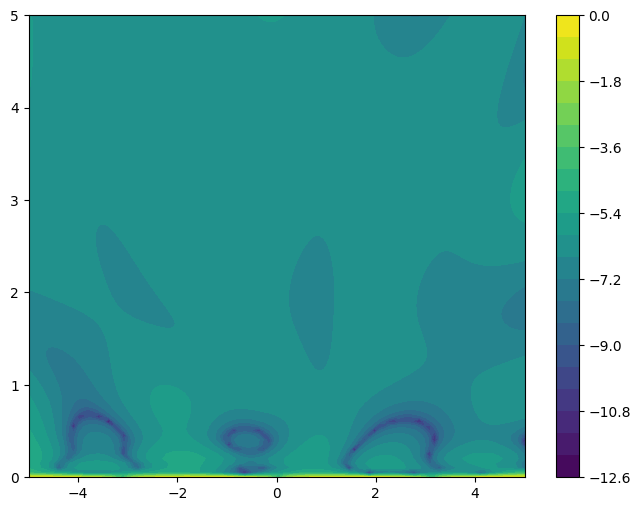

In [7]:
plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_result.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)
y = np.linspace(0, 5, 1000)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

u_result_1 = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_result_1[i,j] = np.log(np.abs(np.sin(X[i,j] - (2/3)*Y[i,j])*np.exp(-(8/3)*Y[i,j])))

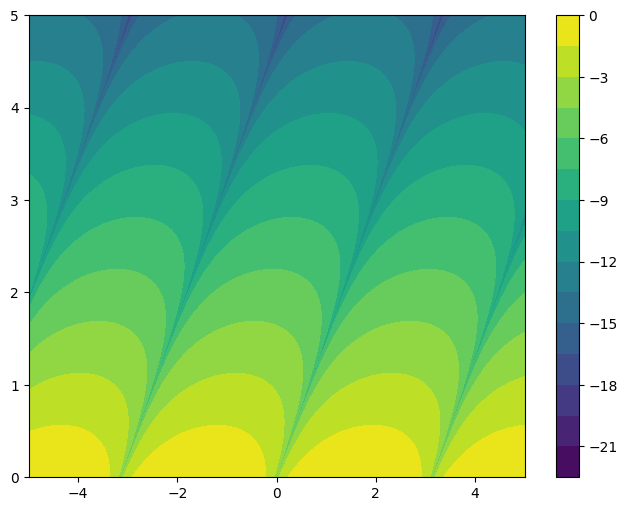

In [9]:
plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_result_1.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

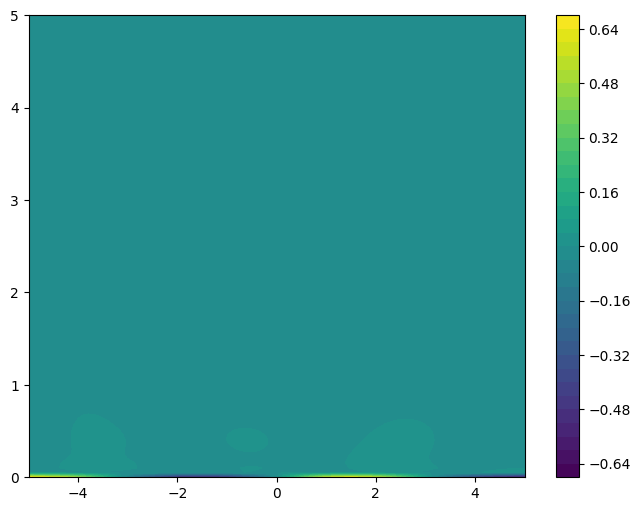

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(0, 5, 100)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

pinn_model = pinn_model.to("cpu")

u_result = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_result[i,j] = pinn_model(torch.Tensor([X[i,j],Y[i,j]]))

plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_result.reshape(X.shape), levels=40)
plt.colorbar()
plt.show()

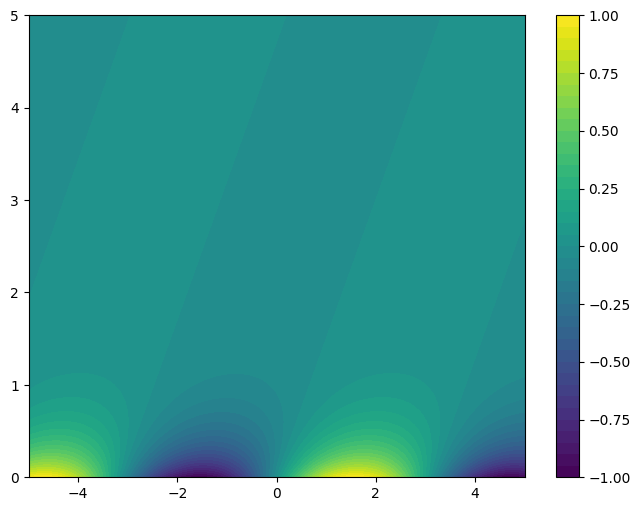

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(0, 5, 100)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

u_result_1 = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_result_1[i,j] = np.sin(X[i,j] - (2/3)*Y[i,j])*np.exp(-(8/3)*Y[i,j])

plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_result_1.reshape(X.shape), levels=40)
plt.colorbar()
plt.show()

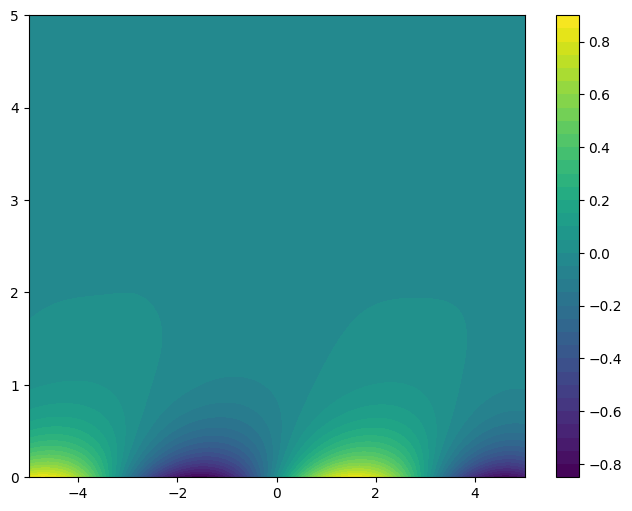

The absolute difference of these things is:-10.655989779176737


In [12]:
plt.figure(figsize=(8,6))
plt.contourf(X, Y, (u_result_1 - u_result), levels=40)
plt.colorbar()
plt.show()
print(f"The absolute difference of these things is: {np.sum(np.abs(u_result_1.reshape(X.shape) - u_result.reshape(X.shape)))}")

In [23]:
(u_result - u_result_1).shape

(100, 100)